In [7]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------------------------------------
# Repo-specific imports

# Add the repo root (e.g.,/fairmast-data-preprocessing) to sys.path
REPO_ROOT = os.path.abspath(os.path.join(
    os.path.dirname(__file__) if '__file__' in globals() else os.getcwd(),
    ".."))  # noqa: E402
print(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.MAST_tools.MAST_dataset import MastDataset
from scripts.pipelines.utils.utils import ComposeTransforms

from scripts.pipelines.transforms.signal_level_transforms.reshape_lcfs_transform import (
ReshapeLcfsTransform
)


# ----------------------------------------------------------------------------------------------------------------------
# Determine device to train on

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing


In [8]:
LOCAL_FLAG = True
train_sh = [14960, 15653, 23172]
source_signal_list_ = [('equilibrium','lcfs_r'), 
                       ('equilibrium','lcfs_z')]

In [14]:
# ..................................................................................................................
# Specific Data Preprocessing for LCFS profiles 

signal_transform_map = {
    var: ComposeTransforms([]) 
    for var in [f'{source}-{signal}' for source, signal in source_signal_list_] }

non_preprocessed_train_dataset = MastDataset(
    local=LOCAL_FLAG,
    shots_list=train_sh,
    source_signal_list=source_signal_list_,
    signal_level_transform_map=None,
    shot_level_transform=None
)

signal_transform_map['equilibrium-lcfs_r'] = ComposeTransforms([ReshapeLcfsTransform()])
signal_transform_map['equilibrium-lcfs_z'] = ComposeTransforms([ReshapeLcfsTransform()])

preprocessed_train_dataset = MastDataset(
    local=LOCAL_FLAG,
    shots_list=train_sh,
    source_signal_list=source_signal_list_,
    signal_level_transform_map=signal_transform_map,
    shot_level_transform=None
)

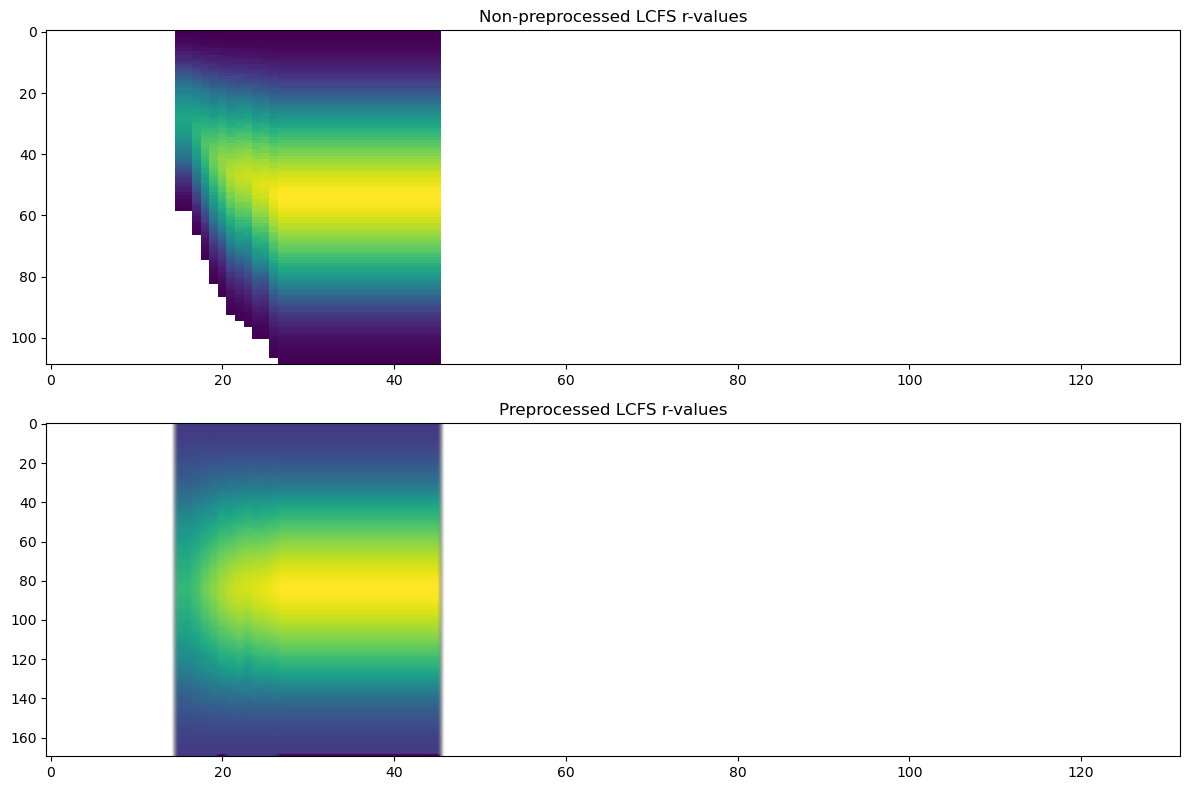

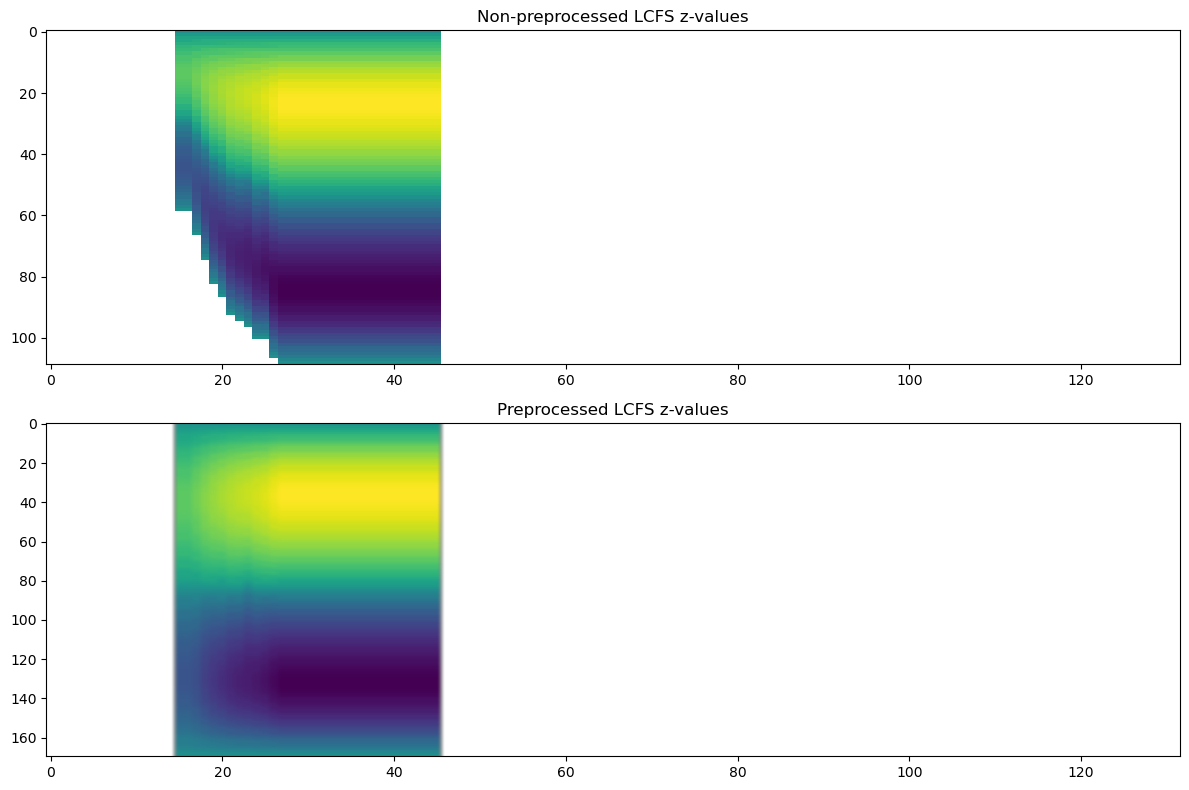

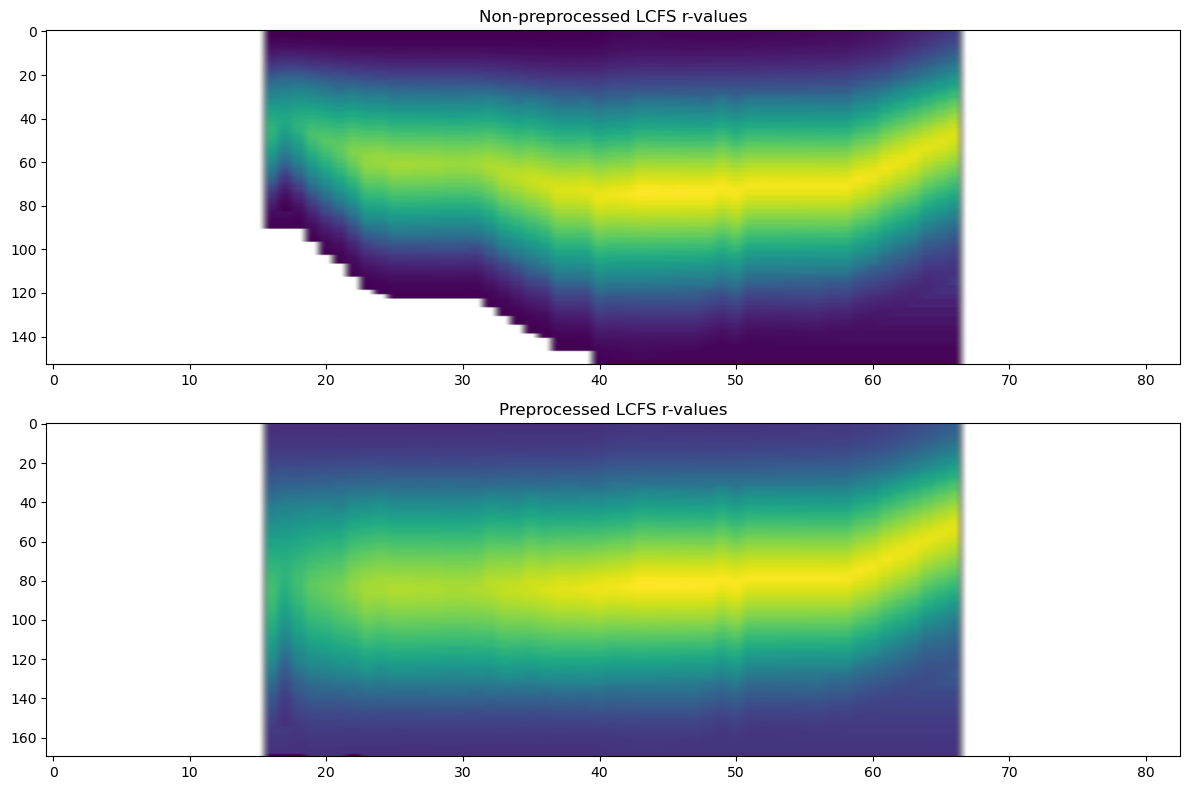

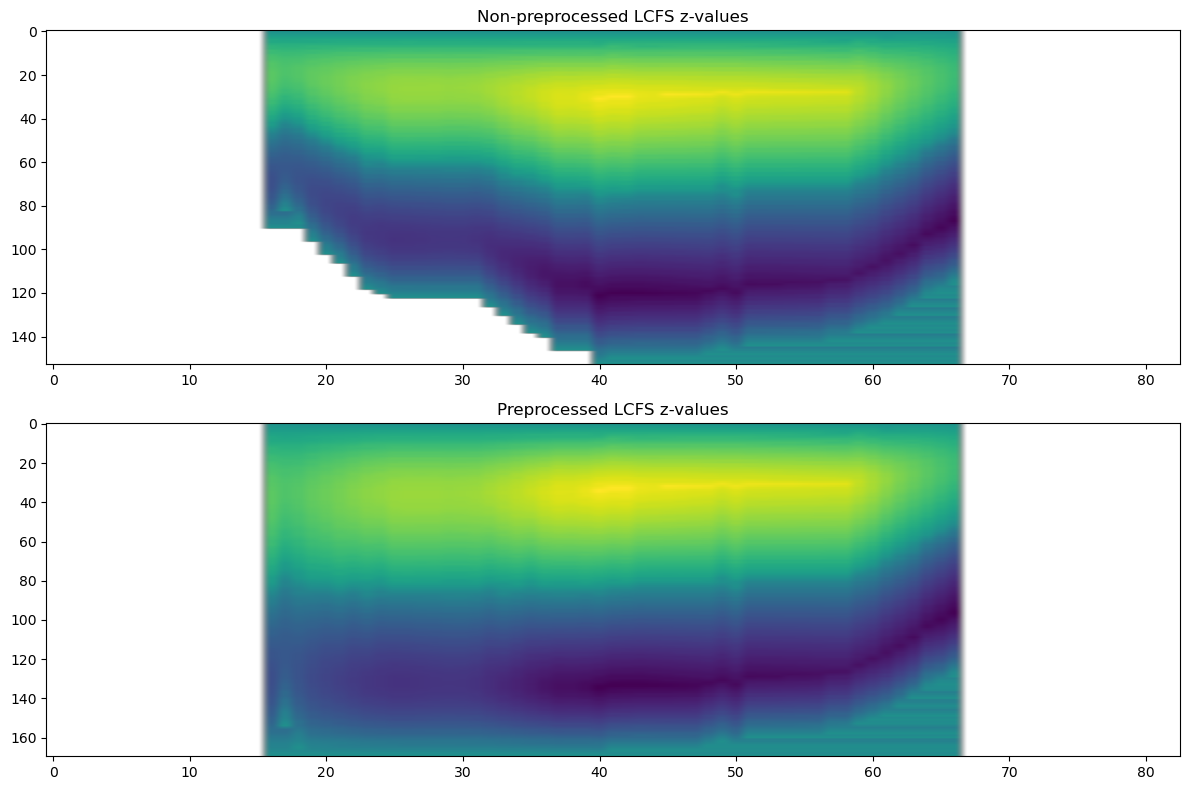

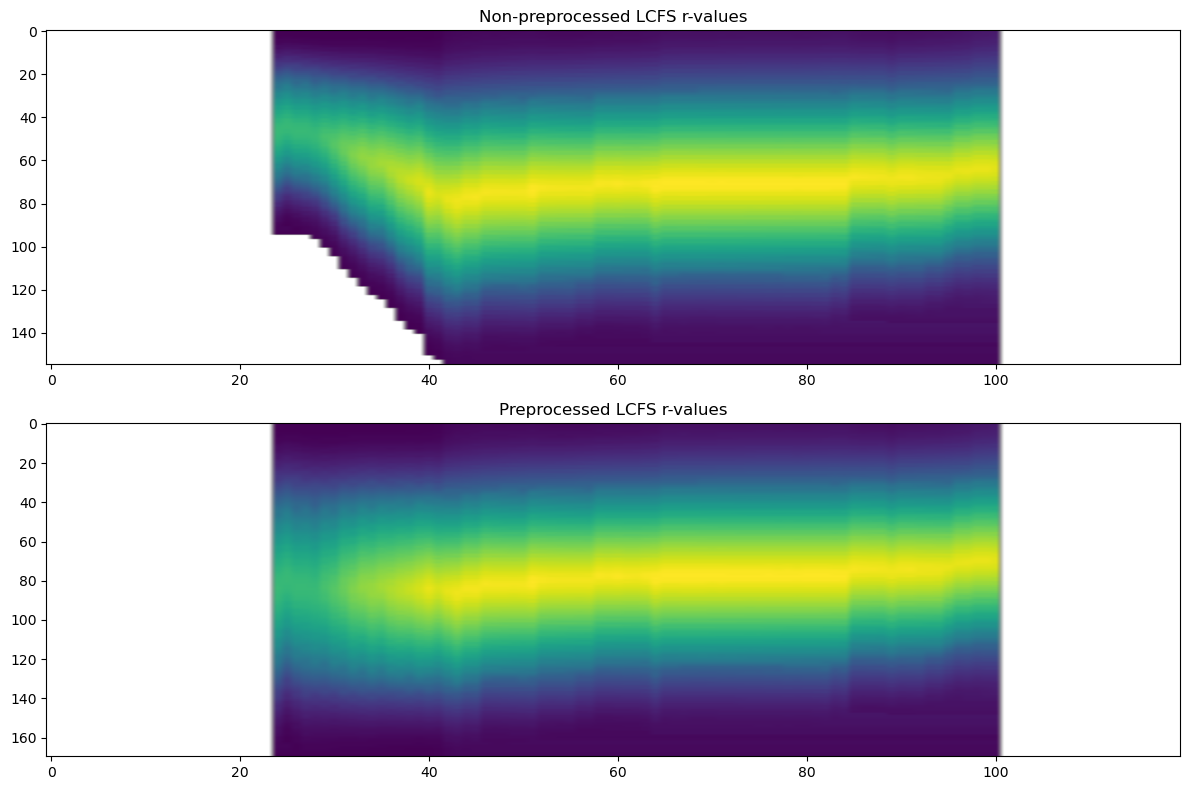

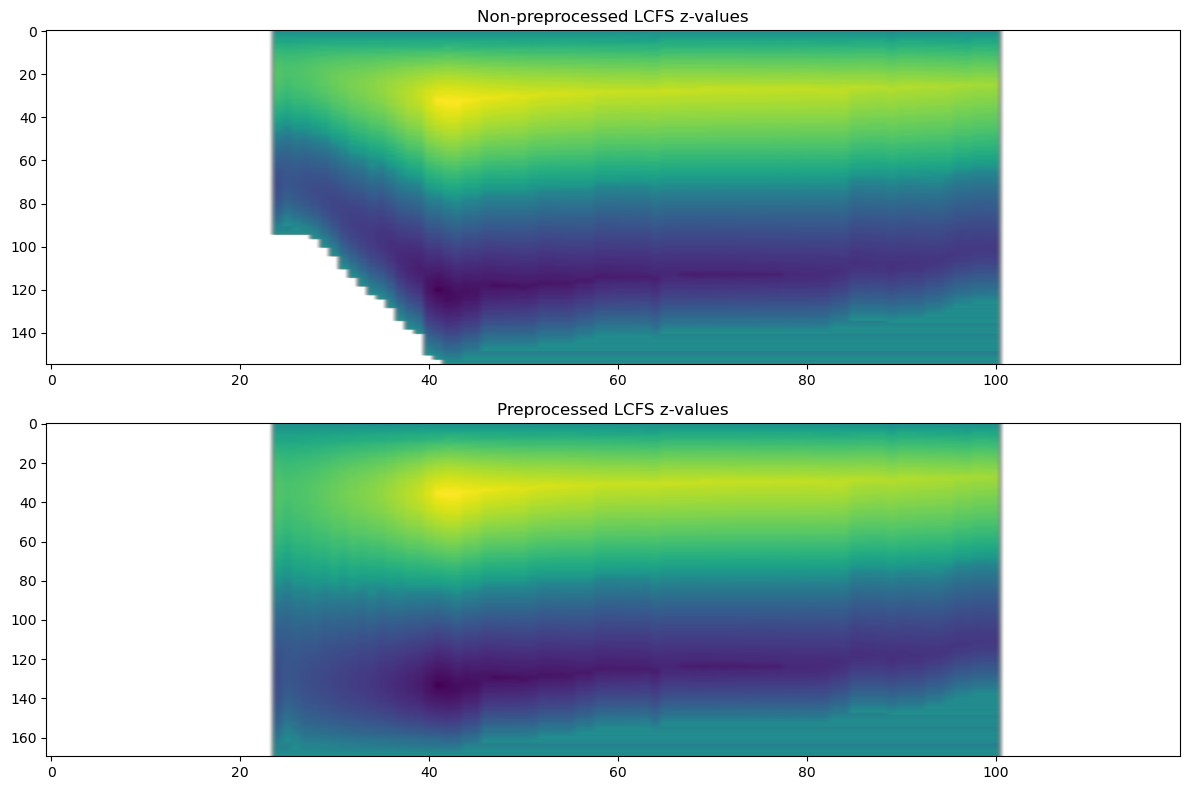

In [16]:
for non_pr_data, pr_data in zip(non_preprocessed_train_dataset, preprocessed_train_dataset):
    
    # === LCFS r-values ===
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # taller figure
    axes[0].imshow(non_pr_data["equilibrium-lcfs_r"]["values"], aspect="auto")
    axes[0].set_title("Non-preprocessed LCFS r-values")
    
    axes[1].imshow(pr_data["equilibrium-lcfs_r"]["values"], aspect="auto")
    axes[1].set_title("Preprocessed LCFS r-values")
    
    plt.tight_layout()
    plt.show()
    
    # === LCFS z-values ===
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # taller figure
    axes[0].imshow(non_pr_data["equilibrium-lcfs_z"]["values"], aspect="auto")
    axes[0].set_title("Non-preprocessed LCFS z-values")
    
    axes[1].imshow(pr_data["equilibrium-lcfs_z"]["values"], aspect="auto")
    axes[1].set_title("Preprocessed LCFS z-values")
    
    plt.tight_layout()
    plt.show()
